In [63]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
print ("Les librairies sont chargées")


Les librairies sont chargées


# Chargement des données

In [64]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")


# Exploration des données(EDA)

In [65]:
orders.info()
orders.head()
orders.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [66]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [67]:
delivered = len(orders[orders["order_status"]=="delivered"])
total = len(orders)
pourcentage = (delivered / total) * 100
print (round(pourcentage, 2), "%")

97.02 %


97 % des commandes ont étés livrées, ce qui indique une bonne performance de la livraison de la plateforme. Les 3 % restants se répartissent entre commandes annulées , en cours de traitement ou indisponibles.

In [68]:
print(orders["order_purchase_timestamp"].min())
print(orders["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


Nos données couvrent la période du 04 septembre 2016 au 17 octobre 2018. Cela veut dire que la liste des commandes que nous avons ont étés passées dans cette période.


# Nettoyage de données ( Data Cleaning )

In [69]:
orders["order_purchase_timestamp"]= pd.to_datetime(orders["order_purchase_timestamp"])
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  str           
 5   order_delivered_carrier_date   97658 non-null  str           
 6   order_delivered_customer_date  96476 non-null  str           
 7   order_estimated_delivery_date  99441 non-null  str           
dtypes: datetime64[us](1), str(7)
memory usage: 6.1 MB


In [70]:
orders_clean = orders[orders["order_status"]=='delivered']
len(orders_clean)

96478

Pour assurer le bon fonctionnement de notre travail, nous avons converti la colonne de dates en datetime et filtré les commandes pour ne garder que les commandes qui ont pour statuts "livrée".

# Analyse SQL

In [71]:
conn = sqlite3.connect(":memory:")

In [72]:
orders_clean.to_sql("orders", conn, index = False, if_exists ="replace")
products.to_sql("products",conn, index = False, if_exists ="replace" )
items.to_sql("items", conn, index = False, if_exists ="replace")
customers.to_sql("customers", conn, index = False, if_exists ="replace")
payments.to_sql("payments", conn, index = False, if_exists ="replace")

103886

Nous venons de transformer les dataframes en tables dans SQL.


In [73]:
query = """
SELECT ROUND(AVG(payment_value),2) AS panier_moyen
FROM payments
"""
pd.read_sql(query, conn)

,panier_moyen
0,154.1


Le panier moyen d'un client est de 154.1

In [74]:
print(orders.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [75]:
print(payments.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [76]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS mois,SUM(payment_value) AS chiffre_affaires
FROM orders
JOIN payments ON orders.order_id = payments.order_id
GROUP BY mois
ORDER BY mois ;
"""

ca_par_mois = pd.read_sql (query, conn)
print(ca_par_mois)

       mois  chiffre_affaires
0   2016-10          46566.71
1   2016-12             19.62
2   2017-01         127545.67
3   2017-02         271298.65
4   2017-03         414369.39
5   2017-04         390952.18
6   2017-05         567066.73
7   2017-06         490225.60
8   2017-07         566403.93
9   2017-08         646000.61
10  2017-09         701169.99
11  2017-10         751140.27
12  2017-11        1153528.05
13  2017-12         843199.17
14  2018-01        1078606.86
15  2018-02         966510.88
16  2018-03        1120678.00
17  2018-04        1132933.95
18  2018-05        1128836.69
19  2018-06        1012090.68
20  2018-07        1027903.86
21  2018-08         985414.28


Le mois le plus rentable a été le mois de novembre 2017 avec un CA de 115000 reais. Cela pourrait s'expliquer par la période car en Novembre se déroule le Black Friday.


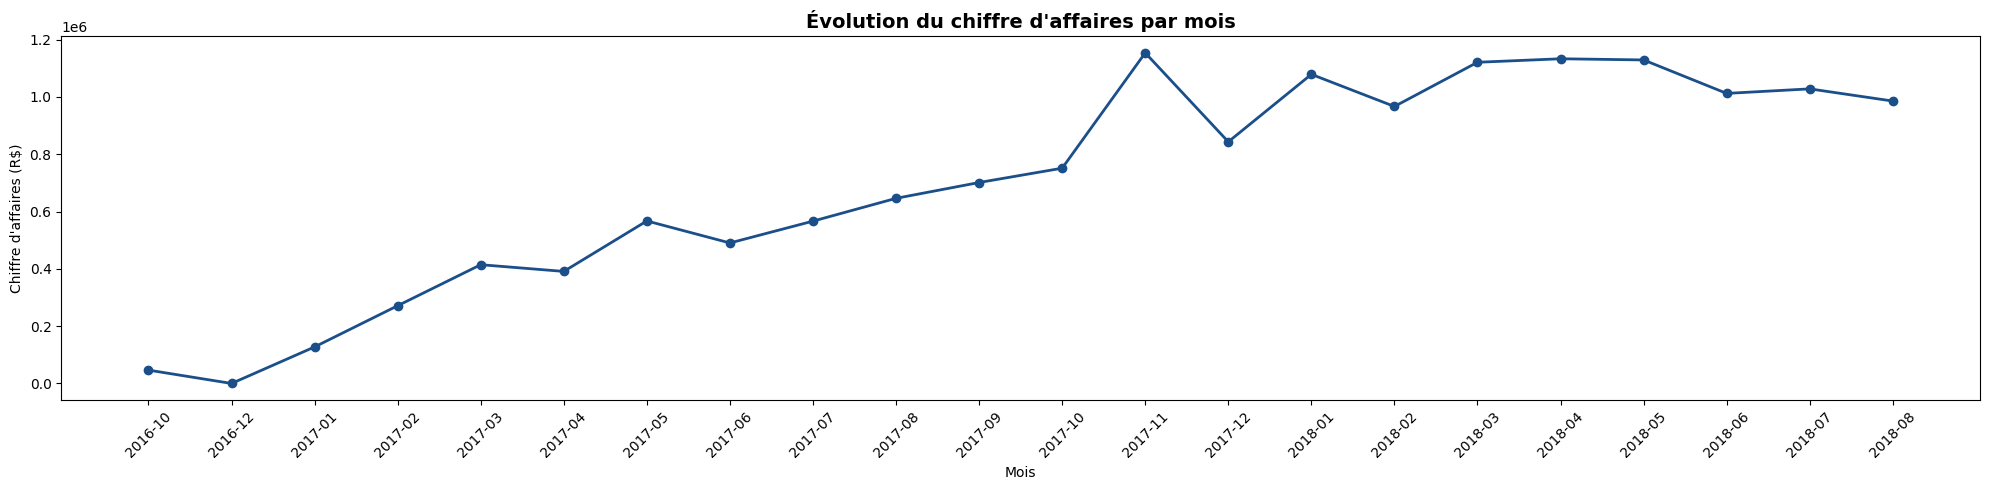

In [77]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(ca_par_mois["mois"], ca_par_mois["chiffre_affaires"], 
        color="#1B4F8A", marker="o", linewidth=2, markersize=6) 
ax.set_title("Évolution du chiffre d'affaires par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Chiffre d'affaires (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/ca_par_mois.png", dpi=150, bbox_inches="tight")
plt.show()

# Analyse du CA par mois

Le chiffre d'affaires de la plateforme Olist montre une croissance 
progressive entre octobre 2016 et novembre 2017, avec quelques fluctuations. 
Un pic important est observé en novembre 2017, ce qui s'explique par le 
Black Friday. Après une légère baisse en décembre 2017, le CA se stabilise 
à un niveau élevé tout au long de 2018, signe de la maturité croissante 
de la plateforme. 
À noter : aucune donnée n'est disponible pour novembre 2016, 
probablement car la plateforme démarrait tout juste.

In [78]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [79]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [80]:
query ="""
SELECT customer_state, AVG(payment_value) AS avg_payment
FROM payments 
JOIN orders ON payments.order_id = orders.order_id 
JOIN customers ON orders.customer_id = customers.customer_id 
GROUP BY customer_state 
ORDER BY avg_payment DESC;
"""

moyenne_ca_par_region = pd.read_sql(query, conn)
print(moyenne_ca_par_region.round(2))

   customer_state  avg_payment
0              PB       250.15
1              AC       235.98
2              AP       233.94
3              AL       229.19
4              RO       226.99
5              RR       220.48
6              PA       216.13
7              PI       208.87
8              SE       204.33
9              TO       203.41
10             MA       201.10
11             MT       199.61
12             CE       198.71
13             RN       197.12
14             MS       186.18
15             PE       185.41
16             AM       182.76
17             BA       169.76
18             GO       163.31
19             SC       162.58
20             DF       161.60
21             RJ       158.08
22             RS       155.45
23             MG       154.12
24             ES       153.62
25             PR       152.45
26             SP       136.39


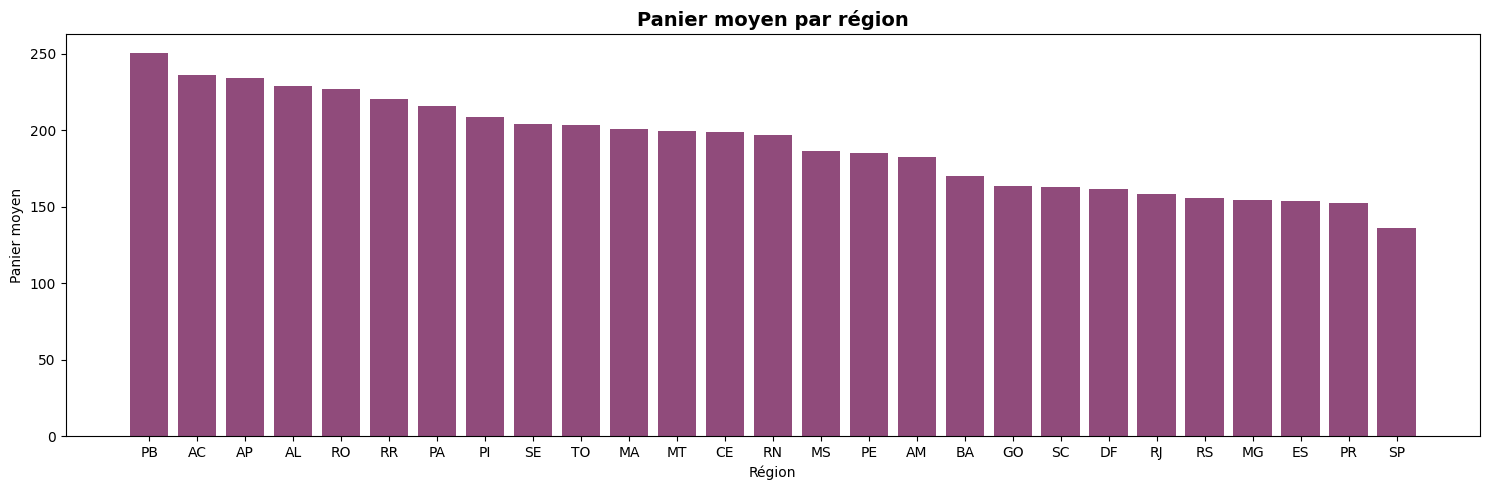

In [81]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(moyenne_ca_par_region["customer_state"],moyenne_ca_par_region["avg_payment"], color ="#904B7B")
plt.title("Panier moyen par région", fontsize=14, fontweight="bold")
plt.xlabel ("Région")
plt.ylabel("Panier moyen")
plt.tight_layout()
plt.savefig("../visuals/panier_moyen_par_region.png", dpi=150, bbox_inches="tight")
plt.show()

# Panier moyen par région
L'état de Paraíba (PB) affiche le panier moyen le plus élevé avec 250 R$, 
suivi de l'Acre (AC) avec 236 R$ et l'Amapá (AP) avec 234 R$. 
De manière surprenante, ce ne sont pas les grands états comme São Paulo 
ou Rio de Janeiro qui ont le panier moyen le plus élevé, mais des états 
du nord et nord-est du Brésil. Cela peut s'expliquer par un accès limité 
aux commerces physiques dans ces régions, poussant les habitants à dépenser 
davantage en ligne.

In [82]:
query =""" SELECT customer_state, SUM(payment_value) AS total_payment 
FROM payments 
JOIN orders ON payments.order_id = orders.order_id 
JOIN customers ON orders.customer_id = customers.customer_id 
GROUP BY customer_state 
ORDER BY total_payment DESC; 
""" 
revenu_total_par_region = pd.read_sql(query, conn) 
print(revenu_total_par_region)

   customer_state  total_payment
0              SP     5770266.19
1              RJ     2055690.45
2              MG     1819277.61
3              RS      861802.40
4              PR      781919.55
5              SC      595208.40
6              BA      591270.60
7              DF      346146.17
8              GO      334294.22
9              ES      317682.65
10             PE      309074.59
11             CE      266463.97
12             PA      212027.55
13             MT      181441.72
14             MA      147807.29
15             PB      137834.65
16             MS      134421.54
17             PI      105272.17
18             RN      100728.30
19             AL       94195.79
20             SE       70289.13
21             TO       60007.37
22             RO       56975.70
23             AM       27596.18
24             AC       19586.25
25             AP       16141.81
26             RR        9039.52


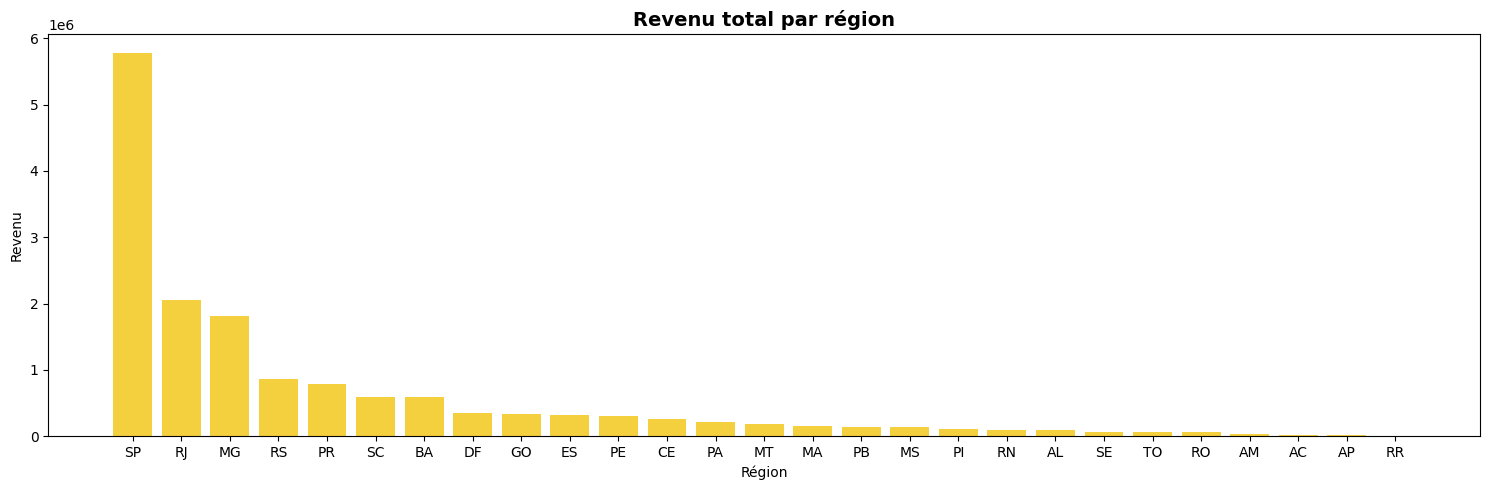

In [83]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(revenu_total_par_region["customer_state"],revenu_total_par_region["total_payment"], color ="#F4D03F")
plt.title("Revenu total par région", fontsize=14, fontweight="bold")
plt.xlabel ("Région")
plt.ylabel("Revenu")
plt.tight_layout()
plt.savefig("../visuals/revenu_total_par_region.png", dpi=150, bbox_inches="tight")
plt.show()